In [4]:
from neuromaps import NeuroMapManuscript

model = NeuroMapManuscript.load("checkpoints/model.ckpt")

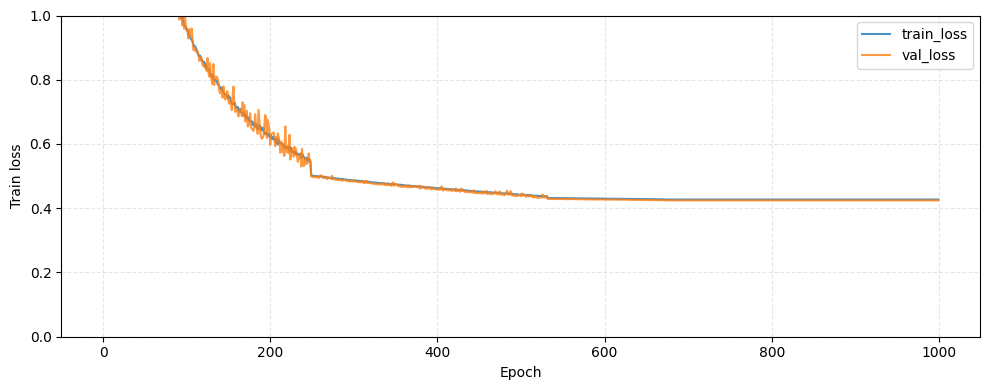

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

plt.style.use('default')
mpl.rcdefaults()

hist = model.training_history

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.plot(np.arange(len(hist["train_loss"])), hist["train_loss"],
        label="train_loss", lw=1.5, alpha=.8)
ax.plot(np.arange(len(hist["val_loss"])), hist["val_loss"],
        label="val_loss", lw=1.5, alpha=.8)

ax.set_xlabel(f"Epoch")
ax.set_ylabel("Train loss")
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, ls="--", alpha=.3)
plt.tight_layout()
plt.show()

In [3]:
from utils import plot_trajectory, get_attractor_trajectory
from systems import vdp_mod2_rk4, vdp_mod2_right_part

u0 = [5, 15]
p = [-0.5, 3]

ode_traj = get_attractor_trajectory(vdp_mod2_rk4, vdp_mod2_right_part, 
                                    u0, p, 0.01, 300, 200, lambda x, y: x[1],
                                    lambda x, y: [0, 1], divergence_threshold=1e4)

plot_trajectory(ode_traj)

2026-04-09 23:05:13 - neuromap_sync.plots - INFO - plot_trajectory:18 - Траектория разбежалась


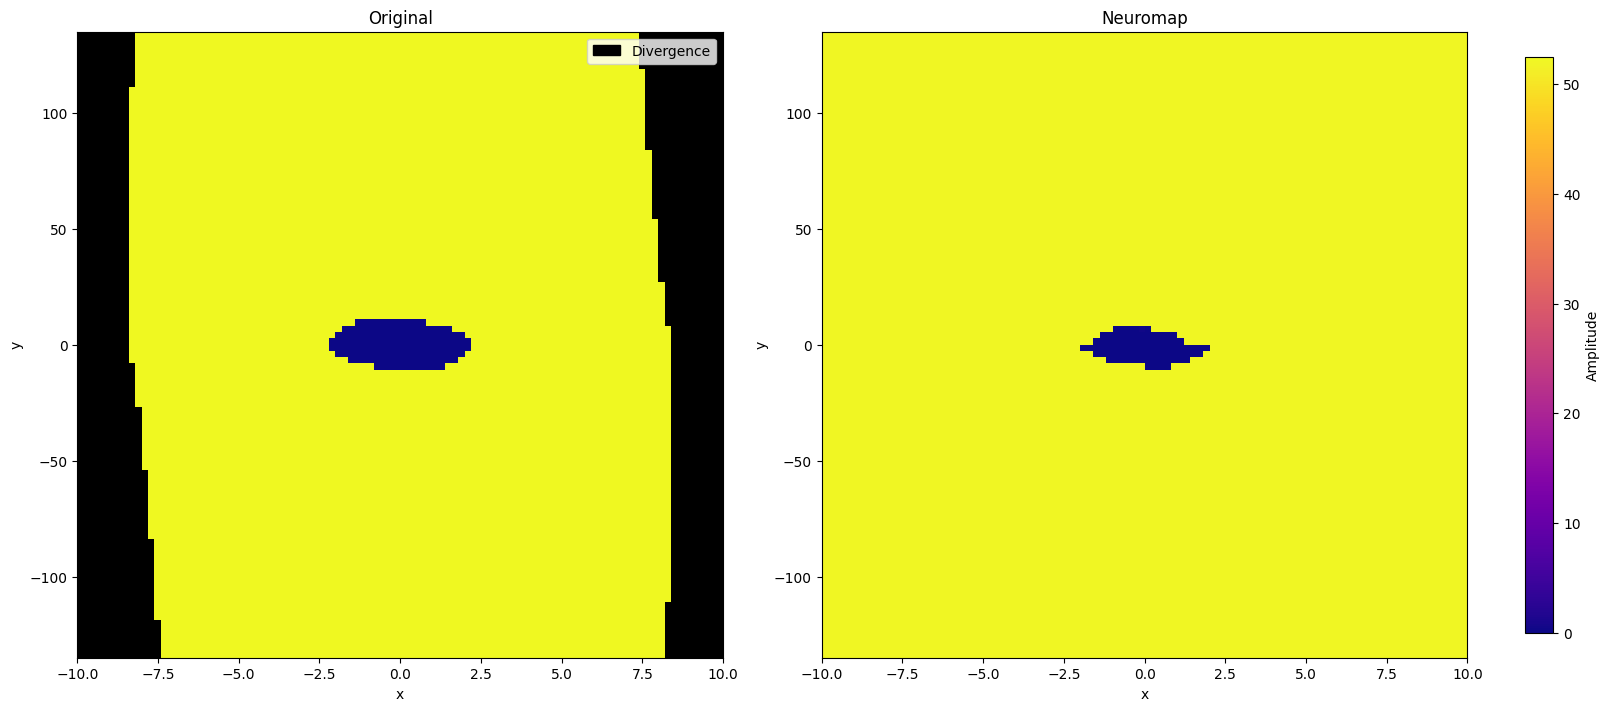

In [4]:
from pathlib import Path

import numpy as np

data_path = Path("results/e1_amplitude_basin.npz")
if not data_path.exists():
    raise FileNotFoundError(
        f"Нет данных: {data_path}. Запустите e1_precompute_amplitude_basins.py (см. комментарий выше)."
    )

_basin = np.load(data_path)
x_grid = _basin["x_grid"]
y_grid = _basin["y_grid"]
Z_ode = _basin["Z_ode"]
Z_nm = _basin["Z_nm"]

from utils import plot_compare_amplitude_basins

plot_compare_amplitude_basins(
    x_grid,
    y_grid,
    Z_ode,
    Z_nm,
    x_label='x',
    y_label='y',
    cmap='plasma',
    bad_color='black',
)

Симуляция: 100%|██████████████████████████████████████████| 20000/20000 [00:00<00:00, 28616.36шаг/s]


2026-04-09 23:05:16 - neuromap_sync.plots - INFO - _plot_2d_trajectories:499 - ODE: divergence


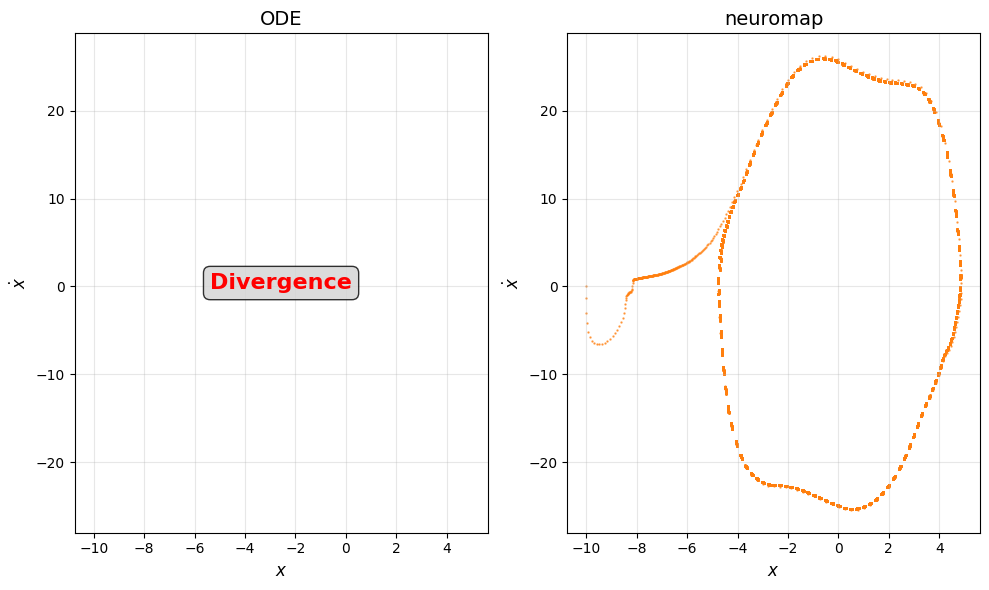

In [5]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import vdp_mod1_rk4, vdp_mod1_right_part

u0 = [-10.0, 0.0]
p = [-1.0, 0.07]

ode_traj = get_attractor_trajectory(vdp_mod1_rk4, vdp_mod1_right_part, 
                                    u0, p, 0.01, 300, 200, lambda x, y: x[1],
                                    lambda x, y: [0, 1], divergence_threshold=1e3)
nm_traj = model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)

plot_compare_trajectories(ode_traj, nm_traj, labels=['ODE', 'neuromap'], layout='sidebyside')

In [6]:
from pathlib import Path

import numpy as np
from utils import plot_heatmap

# Предвычисление — из корня репозитория: python experiments/manuscript/e1_precompute_fixed_point_probability.py
ode_path = Path("results/e1_ode_fixed_point_probability.npz")
if not ode_path.exists():
    raise FileNotFoundError(f"Нет данных: {ode_path}. Запустите e1_precompute_fixed_point_probability.py")

ode_data = np.load(ode_path)
alpha_grid = ode_data["alpha_grid"]
beta_grid = ode_data["beta_grid"]
P_ode = ode_data["P"]

nm_path = Path("results/e1_neuromap_fixed_point_probability.npz")
if not nm_path.exists():
    raise FileNotFoundError(f"Нет данных: {nm_path}. Тот же скрипт создаёт оба файла.")

P_nm = np.load(nm_path)["P"]

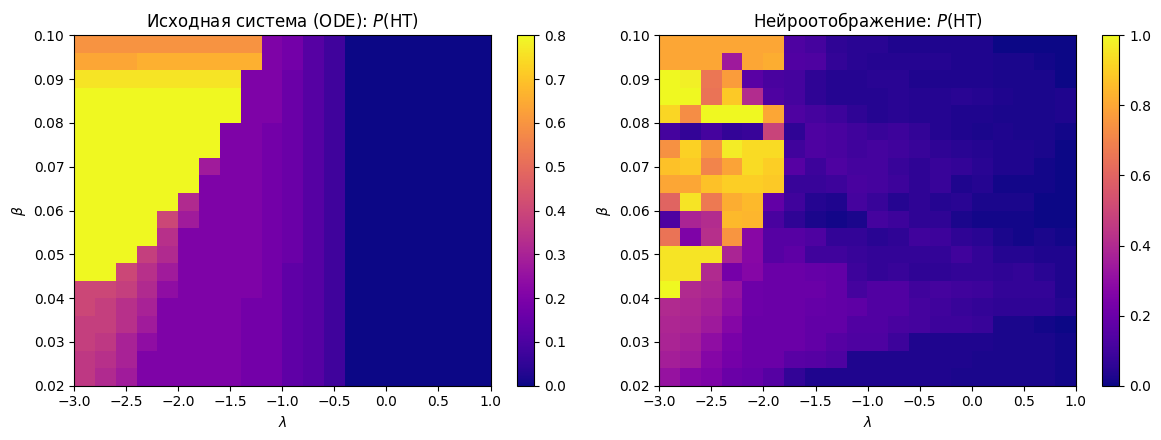

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_heatmap(alpha_grid, beta_grid, P_ode, x_label=r"$\lambda$", y_label=r"$\beta$", ax=axes[0])
axes[0].set_title("Исходная система (ODE): $P(\\mathrm{НТ})$")
plot_heatmap(alpha_grid, beta_grid, P_nm, x_label=r"$\lambda$", y_label=r"$\beta$", ax=axes[1])
axes[1].set_title("Нейроотображение: $P(\\mathrm{НТ})$")
plt.tight_layout()
plt.show()

Симуляция: 100%|██████████████████████████████████████████| 20000/20000 [00:00<00:00, 28241.61шаг/s]

2026-04-10 21:25:11 - neuromap_sync.plots - INFO - _plot_2d_trajectories:499 - ODE: divergence


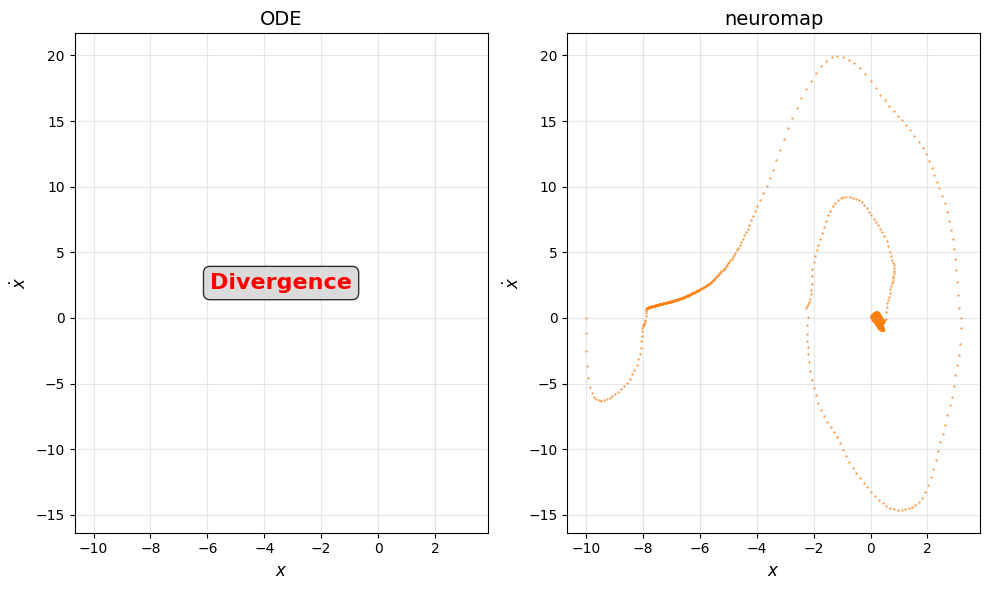

In [5]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import vdp_mod1_rk4, vdp_mod1_right_part

u0 = [-10.0, 0.0]
p = [-2.5, 0.08]

ode_traj = get_attractor_trajectory(vdp_mod1_rk4, vdp_mod1_right_part, 
                                    u0, p, 0.01, 300, 200, lambda x, y: x[1],
                                    lambda x, y: [0, 1], divergence_threshold=1e3)
nm_traj = model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)

plot_compare_trajectories(ode_traj, nm_traj, labels=['ODE', 'neuromap'], layout='sidebyside')

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

data_path = Path("results/e1_neuromap_scan_residual_1em7.npz")
if not data_path.exists():
    raise FileNotFoundError(
        f"Missing precomputed data: {data_path}."
    )

data = np.load(data_path)
lam_grid = data["lam_grid"]
beta_grid = data["beta_grid"]
dist_Z = data["dist_Z"]
log_rho_Z = data["log_rho_Z"]
xg = data["xg"]
yg = data["yg"]

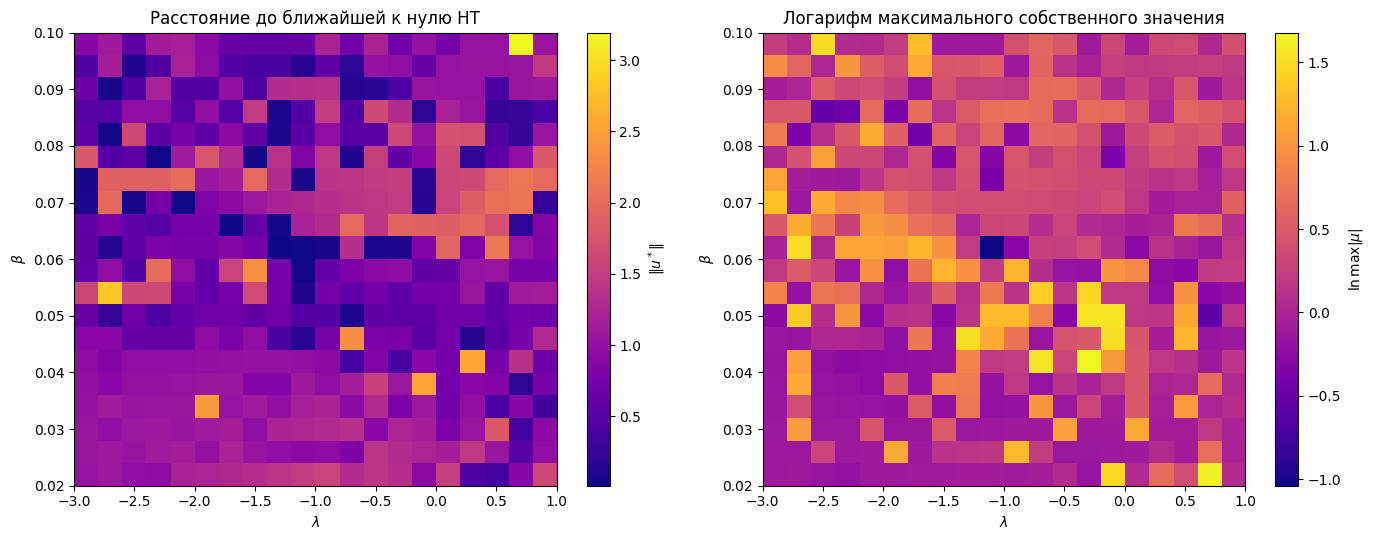

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, Z, ttl, clab in (
    (axes[0], dist_Z, r"Расстояние до ближайшей к нулю НТ", r"$\|u^*\|$"),
    (axes[1], log_rho_Z, r"Логарифм максимального собственного значения", r"$\ln\max|\mu|$"),
):
    im = ax.imshow(
        Z,
        extent=[xg[0], xg[-1], yg[0], yg[-1]],
        origin="lower",
        aspect="auto",
        interpolation="nearest", 
        cmap="plasma",
    )
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(ttl)
    fig.colorbar(im, ax=ax, label=clab)
plt.tight_layout()
plt.show()

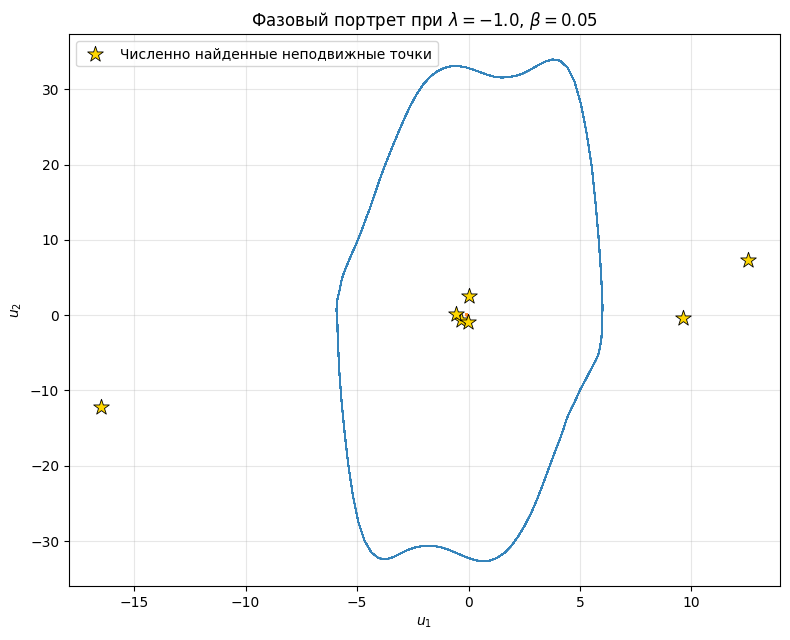

Найдено уникальных НТ: 7
  #0: u = [-16.47727029 -12.1448036 ], ||u|| = 20.4694
  #1: u = [-0.36027808 -0.59113095], ||u|| = 0.692269
  #2: u = [-0.57169671  0.09520643], ||u|| = 0.57957
  #3: u = [0.0269112  2.51801193], ||u|| = 2.51816
  #4: u = [-0.03409374 -0.9610181 ], ||u|| = 0.961623
  #5: u = [ 9.61479929 -0.37782613], ||u|| = 9.62222
  #6: u = [12.520595    7.28371947], ||u|| = 14.4851


In [11]:
import numpy as np
import matplotlib.pyplot as plt

from utils.nn_map_fixed_points import collect_fixed_points_grid_starts

# --- фиксированные параметры карты (λ, β); измените при необходимости ---
lam, beta = -1.0, 0.05
p_fixed = [float(lam), float(beta)]
p_2d = np.array([[lam, beta]], dtype=np.float64)

# --- поиск неподвижных точек: декартово произведение осевых сеток стартов ---
u0_u1 = np.linspace(-15.0, 15.0, 12)
u0_u2 = np.linspace(-35.0, 35.0, 12)
fixed_pts = collect_fixed_points_grid_starts(
    model,
    p_fixed,
    (u0_u1, u0_u2),
    residual_tol=1e-7,
    unique_tol=1e-3,
)

# --- начальные условия: список пар (u1, u2) ---
initial_conditions = [
    (5.0, 20.0),
    (0.0, 0.5),
]

n_steps = 8000
n_transient = 1000  # отбросить первые шаги перед отрисовкой

fig, ax = plt.subplots(figsize=(8, 6.5))
for u1, u2 in initial_conditions:
    u0 = np.array([[u1, u2]], dtype=np.float64)
    traj = model.simulate(u0, p_2d, n_steps, verbose=False)
    if traj is None:
        ax.plot([u1], [u2], "rx", ms=8, label="_nolegend_")
        continue
    traj = traj[n_transient:]
    if len(traj) < 2:
        continue
    ax.plot(traj[:, 0], traj[:, 1], lw=0.9, alpha=0.9)

if fixed_pts:
    fp = np.stack([np.asarray(u, dtype=float).ravel() for u in fixed_pts], axis=0)
    ax.scatter(
        fp[:, 0],
        fp[:, 1],
        s=140,
        marker="*",
        c="gold",
        edgecolors="black",
        linewidths=0.6,
        zorder=6,
        label="Численно найденные неподвижные точки",
    )
else:
    ax.text(
        0.02,
        0.98,
        "НТ не найдены (см. сетку стартов / residual_tol)",
        transform=ax.transAxes,
        va="top",
    )

ax.set_xlabel(r"$u_1$")
ax.set_ylabel(r"$u_2$")
ax.set_title(rf"Фазовый портрет при $\lambda={lam}$, $\beta={beta}$")
ax.grid(True, alpha=0.3)
if fixed_pts:
    ax.legend(loc="best")
plt.tight_layout()
plt.show()

print(f"Найдено уникальных НТ: {len(fixed_pts)}")
for i, u in enumerate(fixed_pts):
    print(f"  #{i}: u = {np.asarray(u).ravel()}, ||u|| = {np.linalg.norm(u):.6g}")

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

data_path = Path("results/e1_neuromap_scan_residual_1em10.npz")
if not data_path.exists():
    raise FileNotFoundError(
        f"Missing precomputed data: {data_path}."
    )

data = np.load(data_path)
lam_grid = data["lam_grid"]
beta_grid = data["beta_grid"]
dist_Z = data["dist_Z"]
log_rho_Z = data["log_rho_Z"]
xg = data["xg"]
yg = data["yg"]

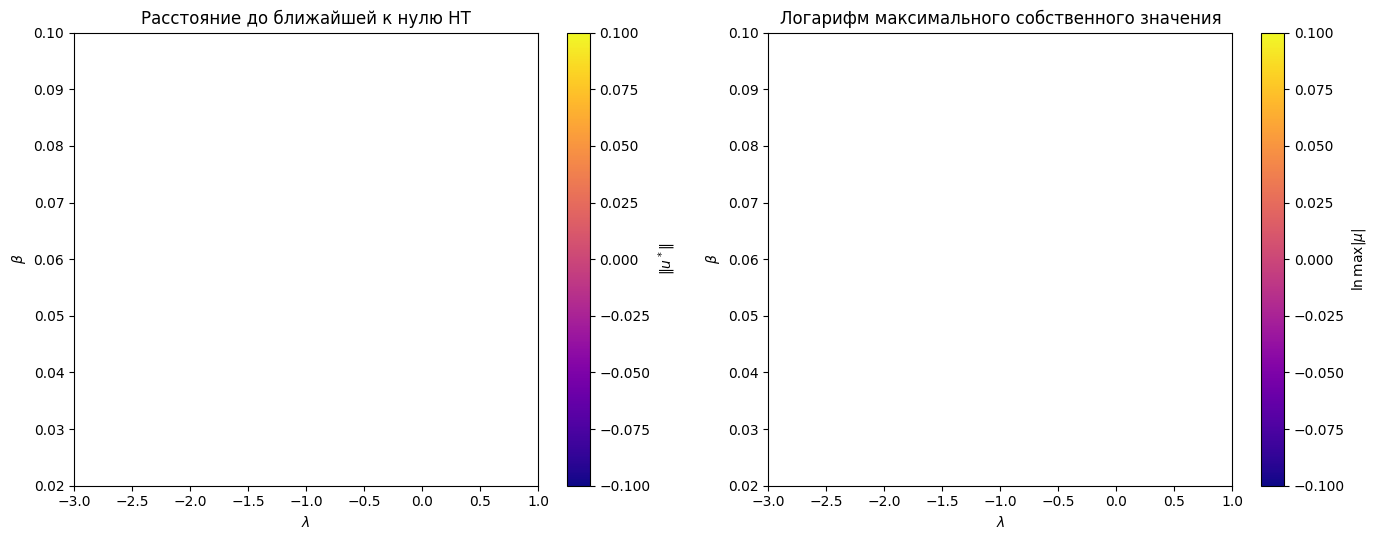

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, Z, ttl, clab in (
    (axes[0], dist_Z, r"Расстояние до ближайшей к нулю НТ", r"$\|u^*\|$"),
    (axes[1], log_rho_Z, r"Логарифм максимального собственного значения", r"$\ln\max|\mu|$"),
):
    im = ax.imshow(
        Z,
        extent=[xg[0], xg[-1], yg[0], yg[-1]],
        origin="lower",
        aspect="auto",
        interpolation="nearest", 
        cmap="plasma",
    )
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(ttl)
    fig.colorbar(im, ax=ax, label=clab)
plt.tight_layout()
plt.show()

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

data_path = Path("results/e1_neuromap_scan_residual_1em8.npz")
if not data_path.exists():
    raise FileNotFoundError(
        f"Missing precomputed data: {data_path}."
    )

data = np.load(data_path)
lam_grid = data["lam_grid"]
beta_grid = data["beta_grid"]
dist_Z = data["dist_Z"]
log_rho_Z = data["log_rho_Z"]
xg = data["xg"]
yg = data["yg"]

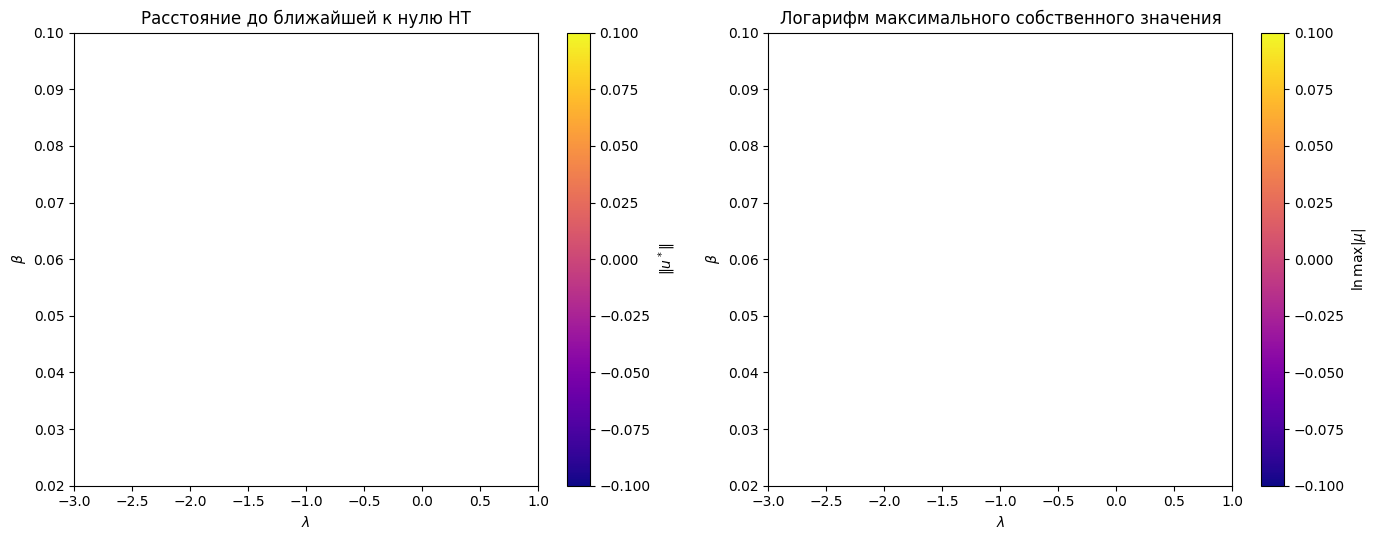

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, Z, ttl, clab in (
    (axes[0], dist_Z, r"Расстояние до ближайшей к нулю НТ", r"$\|u^*\|$"),
    (axes[1], log_rho_Z, r"Логарифм максимального собственного значения", r"$\ln\max|\mu|$"),
):
    im = ax.imshow(
        Z,
        extent=[xg[0], xg[-1], yg[0], yg[-1]],
        origin="lower",
        aspect="auto",
        interpolation="nearest", 
        cmap="plasma",
    )
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(ttl)
    fig.colorbar(im, ax=ax, label=clab)
plt.tight_layout()
plt.show()

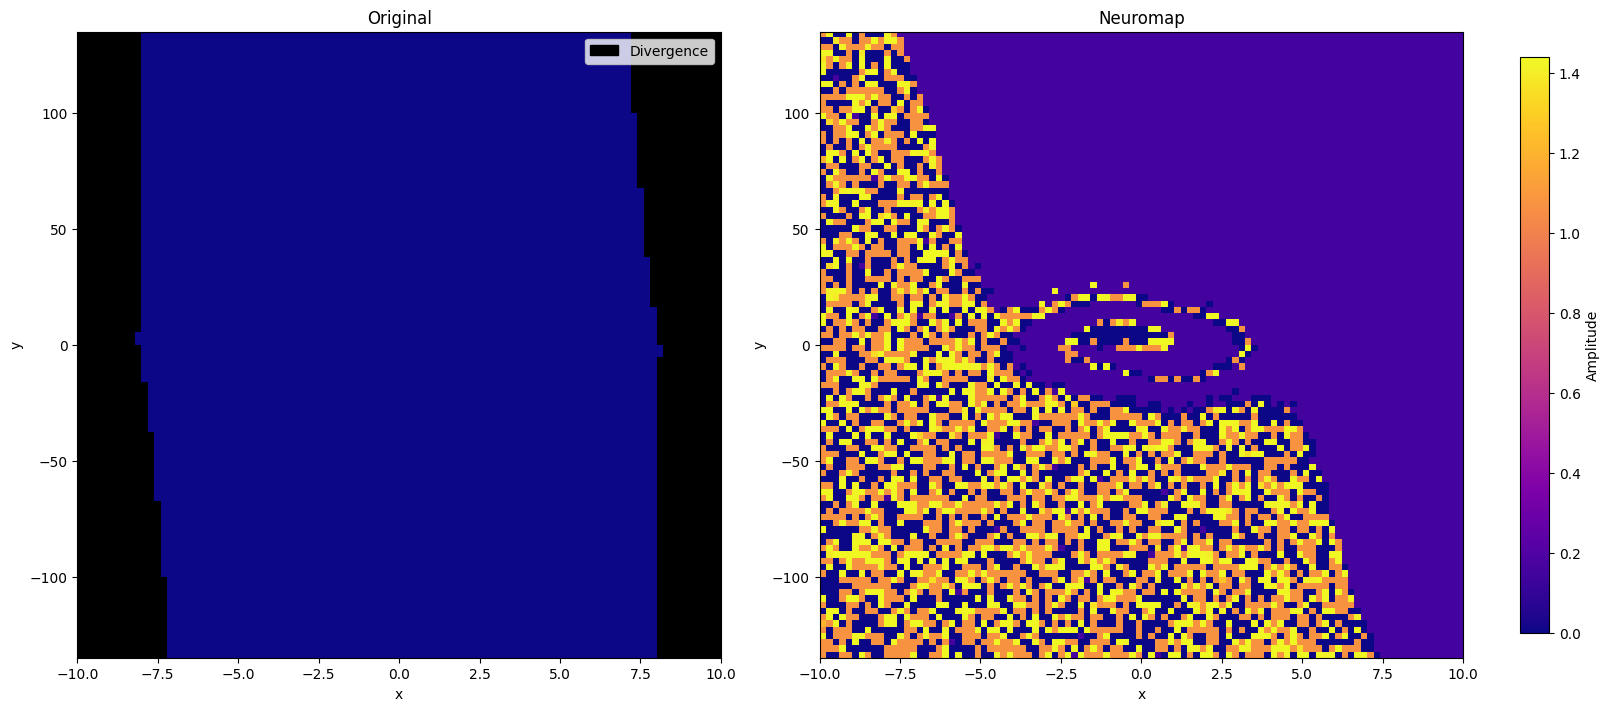

In [10]:
from pathlib import Path

import numpy as np

data_path = Path("results/e1_amplitude_basin_1.npz")
if not data_path.exists():
    raise FileNotFoundError(
        f"Нет данных: {data_path}. Запустите e1_precompute_amplitude_basins.py (см. комментарий выше)."
    )

_basin = np.load(data_path)
x_grid = _basin["x_grid"]
y_grid = _basin["y_grid"]
Z_ode = _basin["Z_ode"]
Z_nm = _basin["Z_nm"]

from utils import plot_compare_amplitude_basins

plot_compare_amplitude_basins(
    x_grid,
    y_grid,
    Z_ode,
    Z_nm,
    x_label='x',
    y_label='y',
    cmap='plasma',
    bad_color='black',
)